# GatedFusion Weight Analysis
Checkpoint: `runs/protected/three_seeds/20260301-205342__ctmp_gin__bs=256__lr=2.00e-04__seed=1/checkpoints/best.pt`

In [1]:
import os
import sys

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.data_processing.tensor_dataset import TEDSTensorDataset
from src.data_processing.data_utils import train_test_split_stratified
from src.models.factory import build_model, build_edge
from src.utils.device_set import device_set

print("PROJECT_ROOT:", PROJECT_ROOT)

/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /Users/jeong-yunseong/Documents/programming/Phase_2_public


## 1. Config & Paths

In [2]:
RUN_DIR = os.path.join(
    PROJECT_ROOT,
    "runs", "protected", "three_seeds",
    "20260301-205342__ctmp_gin__bs=256__lr=2.00e-04__seed=1"
)
CKPT_PATH = os.path.join(RUN_DIR, "checkpoints", "best.pt")
CFG_PATH  = os.path.join(RUN_DIR, "config.final.yaml")
DATA_ROOT = os.path.join(PROJECT_ROOT, "src", "data")

assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
assert os.path.exists(CFG_PATH),  f"Config not found: {CFG_PATH}"

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

print(yaml.dump(cfg, default_flow_style=False))

cv:
  cv: true
device: null
edge:
  edge_cached: true
  is_mi_based: true
  n_neighbors: 7
  pruning_ratio: 0.7
  return_edge_attr: false
  threshold: 0.01
  top_k: 9
model:
  name: ctmp_gin
  params:
    dropout_p: 0.018503542107251567
    embedding_dim: 16
    gate_hidden_ch: 128
    gin_1_layers: 3
    gin_2_layers: 3
    gin_hidden_channel: 96
    gin_hidden_channel_2: 96
    los_embedding_dim: 4
    train_eps: false
train:
  batch_size: 256
  binary: true
  cv: false
  decision_threshold: 0.5
  early_stopping_patience: 10
  epochs: 100
  ig_label: false
  learning_rate: 0.0002000054566973331
  lr_scheduler_patience: 5
  n_folds: 5
  num_workers: 4
  optimizer: adamw
  seed: 1
  test_ratio: 0.15
  train_ratio: 0.7
  val_ratio: 0.15
  weight_decay: 1.0482209742775742e-05



## 2. Dataset & Split

In [3]:
seed       = cfg["train"]["seed"]          # 1
batch_size = cfg["train"]["batch_size"]    # 256
split_ratio = [
    cfg["train"]["train_ratio"],
    cfg["train"]["val_ratio"],
    cfg["train"]["test_ratio"],
]

dataset = TEDSTensorDataset(
    root=DATA_ROOT,
    binary=cfg["train"]["binary"],
    ig_label=cfg["train"].get("ig_label", False),
    remove_los=True,
)

# Replicate the same stratified split used during training (same seed)
train_loader, val_loader, test_loader, idx = train_test_split_stratified(
    dataset=dataset,
    batch_size=batch_size,
    ratio=split_ratio,
    seed=seed,
    num_workers=0,
)
train_idx, val_idx, test_idx = idx
train_df = dataset.processed_df.iloc[train_idx]

print(f"num_classes: {dataset.num_classes}")

Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123
num_classes: 2


## 3. Build Model & Load Checkpoint

In [4]:
device = device_set(cfg["device"])

model_params = dict(cfg["model"]["params"])
model_params["col_info"]    = dataset.col_info
model_params["num_classes"] = dataset.num_classes
model_params["device"]      = device

model = build_model(model_name=cfg["model"]["name"], **model_params)

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
model.to(device)
print("Checkpoint loaded. Epoch:", ckpt.get("epoch", "N/A"))

Using device: mps
Using manually specified device: mps
Checkpoint loaded. Epoch: 31


## 4. Build Edge Index

In [5]:
num_nodes = len(dataset.col_info[2])  # len(ad_col_index)

edge_index = build_edge(
    model_name=cfg["model"]["name"],
    root=DATA_ROOT,
    seed=seed,
    train_df=train_df,
    num_nodes=num_nodes,
    batch_size=batch_size,
    **cfg.get("edge", {})
)
edge_index = edge_index.to(device)
print("edge_index shape:", edge_index.shape)

Buliding Edge Index Based on Mutual Information
Loading cached file...
edge_index shape: torch.Size([2, 398848])


## 5. Collect GatedFusion Weights via Forward Hook

In [6]:
# GatedFusion.forward returns (fused, w, logits)
# w shape: [B, 3]  ->  columns = [w_ad, w_dis, w_merged]

all_w      = []  # fusion weights
all_labels = []  # ground-truth labels
all_preds  = []  # predicted probabilities

def _hook(module, input, output):
    """Capture the softmax weight tensor w from GatedFusion output."""
    _, w, _ = output          # (fused, w, logits)
    all_w.append(w.detach().cpu())

hook_handle = model.gated_fusion.register_forward_hook(_hook)

# Use the full dataset loader (no drop_last so we catch every sample)
full_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                         num_workers=0, drop_last=False)

with torch.no_grad():
    for x_batch, y_batch, los_batch in tqdm(full_loader, desc="Collecting weights"):
        x_batch   = x_batch.to(device)
        los_batch = los_batch.to(device)
        y_batch   = y_batch.to(device)

        logits = model(x_batch, los_batch, edge_index, device=device)
        probs  = torch.sigmoid(logits.squeeze(1)).cpu()

        all_labels.append(y_batch.cpu())
        all_preds.append(probs)

hook_handle.remove()

W      = torch.cat(all_w,      dim=0).numpy()   # (N, 3)
labels = torch.cat(all_labels, dim=0).numpy()   # (N,)
preds  = torch.cat(all_preds,  dim=0).numpy()   # (N,)

print(f"W shape: {W.shape}, labels: {labels.shape}")

W shape: (1394138, 3), labels: (1394138,)


## 6. Summary Statistics

In [30]:
df_w = pd.DataFrame(W, columns=["w_ad", "w_dis", "w_merged"])
df_w["label"] = labels
df_w["pred"]  = preds

print("=== Overall mean weights ===")
print(df_w[["w_ad", "w_dis", "w_merged"]].mean().to_string())
print()
print("=== Mean weights by class ===")
print(df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].mean().to_string())
print()
print("=== Std weights by class ===")
print(df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].std().to_string())


=== Overall mean weights ===
w_ad        0.189730
w_dis       0.481602
w_merged    0.328224

=== Mean weights by class ===
           w_ad     w_dis  w_merged
label                              
0      0.122716  0.590552  0.286732
1      0.274167  0.345609  0.380224

=== Std weights by class ===
          w_ad     w_dis  w_merged
label                             
0      0.14582  0.304880  0.293775
1      0.34383  0.312437  0.331263


In [31]:
df_w.to_csv("Gated_Fusion_weight_seed_1.csv")

## 7. Visualisation

In [17]:
import pandas as pd

df_w = pd.read_csv("Gated_Fusion_weight_seed_1.csv")

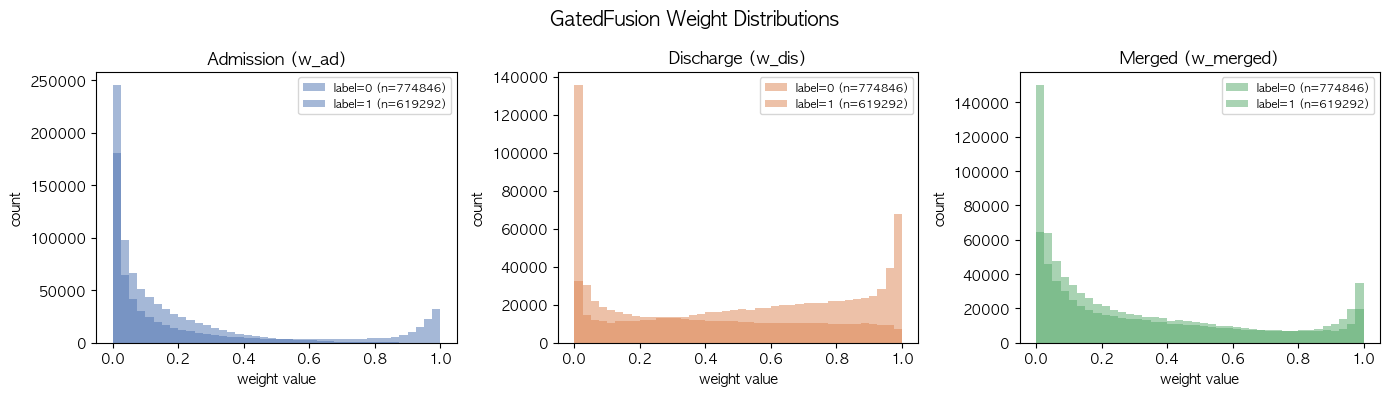

In [29]:
COMPONENT_NAMES = ["Admission (w_ad)", "Discharge (w_dis)", "Merged (w_merged)"]
COLORS = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle("GatedFusion Weight Distributions", fontsize=14, fontweight="bold")

for i, (ax, name, color) in enumerate(zip(axes, COMPONENT_NAMES, COLORS)):
    col = ["w_ad", "w_dis", "w_merged"][i]
    for cls_val, ls in zip([0, 1], ["--", "-"]):
        subset = df_w.loc[df_w["label"] == cls_val, col]
        ax.hist(subset, bins=40, alpha=0.5, color=color, linestyle=ls,
                label=f"label={int(cls_val)} (n={len(subset)})")
    ax.set_title(name)
    ax.set_xlabel("weight value")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

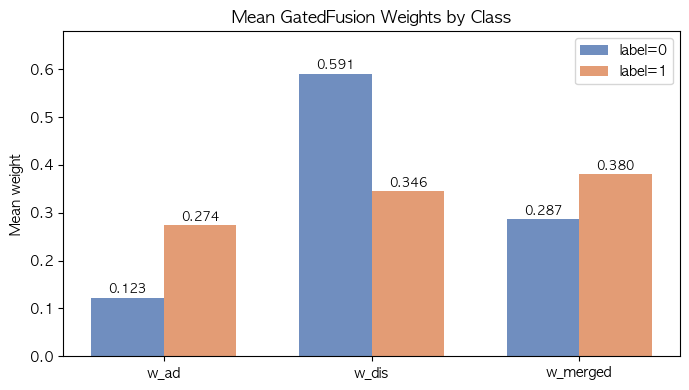

In [30]:
# Bar chart: mean weight per component, split by class
mean_by_class = df_w.groupby("label")[["w_ad", "w_dis", "w_merged"]].mean()

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars0 = ax.bar(x - width/2, mean_by_class.loc[0], width, label="label=0", color="#4C72B0", alpha=0.8)
bars1 = ax.bar(x + width/2, mean_by_class.loc[1], width, label="label=1", color="#DD8452", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(["w_ad", "w_dis", "w_merged"])
ax.set_ylabel("Mean weight")
ax.set_title("Mean GatedFusion Weights by Class")
ax.legend()

# y축 상한을 데이터 최대값 + 여백으로 동적 설정
max_val = mean_by_class.values.max()
ax.set_ylim(0, max_val * 1.15)

for bar in bars0:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
df_w

,Unnamed: 0,w_ad,w_dis,w_merged,label,pred
0,0,0.190542,0.590874,0.218583,0,0.358261
1,1,0.265227,0.518262,0.216511,0,0.014792
2,2,0.121808,0.705412,0.172780,0,0.043621
3,3,0.067958,0.363547,0.568495,0,0.127844
4,4,0.008828,0.539564,0.451608,0,0.334110
...,...,...,...,...,...,...
1394133,1394133,0.194296,0.677479,0.128225,0,0.037031
1394134,1394134,0.130755,0.329500,0.539745,0,0.238190
1394135,1394135,0.030140,0.466082,0.503778,1,0.319153
1394136,1394136,0.204992,0.709174,0.085834,0,0.009050


In [42]:
raw_df = pd.read_csv(os.path.join(DATA_ROOT, 'raw', 'TEDS_Discharge.csv'))
raw_df

,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2022,1339846,2,3,1,7,-9,36,1,1,...,0,0,0,0,1,9,4,0,3,-9
1,2022,1253743,51,3,-9,7,-9,1,6,0,...,0,0,0,0,0,5,3,1,3,-9
2,2022,1233061,2,3,1,7,-9,34,1,1,...,0,0,0,0,1,9,4,0,3,-9
3,2022,1199513,2,3,-9,7,-9,36,1,0,...,0,0,0,0,0,9,4,1,3,-9
4,2022,1267731,2,3,2,7,-9,37,1,1,...,0,0,0,0,0,9,4,0,1,-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394133,2022,1539515,56,2,2,6,3,31,7,0,...,0,0,0,0,0,8,4,1,3,-9
1394134,2022,1518665,56,3,1,6,3,33,7,0,...,0,0,0,0,0,8,4,0,3,-9
1394135,2022,1244927,56,3,1,7,-9,34,1,0,...,0,0,0,0,0,8,4,0,1,-9
1394136,2022,1156949,56,3,1,7,6,31,7,0,...,0,0,0,0,0,8,4,0,3,-9


In [43]:
los = raw_df['LOS'][:1393920].copy()
los

0          36
1           1
2          34
3          36
4          37
           ..
1393915    30
1393916    27
1393917     4
1393918    22
1393919    35
Name: LOS, Length: 1393920, dtype: int64

In [44]:
df_w_los = df_w.copy()
df_w_los["LOS"] = los
df_w_los

,Unnamed: 0,w_ad,w_dis,w_merged,label,pred,LOS
0,0,0.190542,0.590874,0.218583,0,0.358261,36.0
1,1,0.265227,0.518262,0.216511,0,0.014792,1.0
2,2,0.121808,0.705412,0.172780,0,0.043621,34.0
3,3,0.067958,0.363547,0.568495,0,0.127844,36.0
4,4,0.008828,0.539564,0.451608,0,0.334110,37.0
...,...,...,...,...,...,...,...
1394133,1394133,0.194296,0.677479,0.128225,0,0.037031,NaN
1394134,1394134,0.130755,0.329500,0.539745,0,0.238190,NaN
1394135,1394135,0.030140,0.466082,0.503778,1,0.319153,NaN
1394136,1394136,0.204992,0.709174,0.085834,0,0.009050,NaN


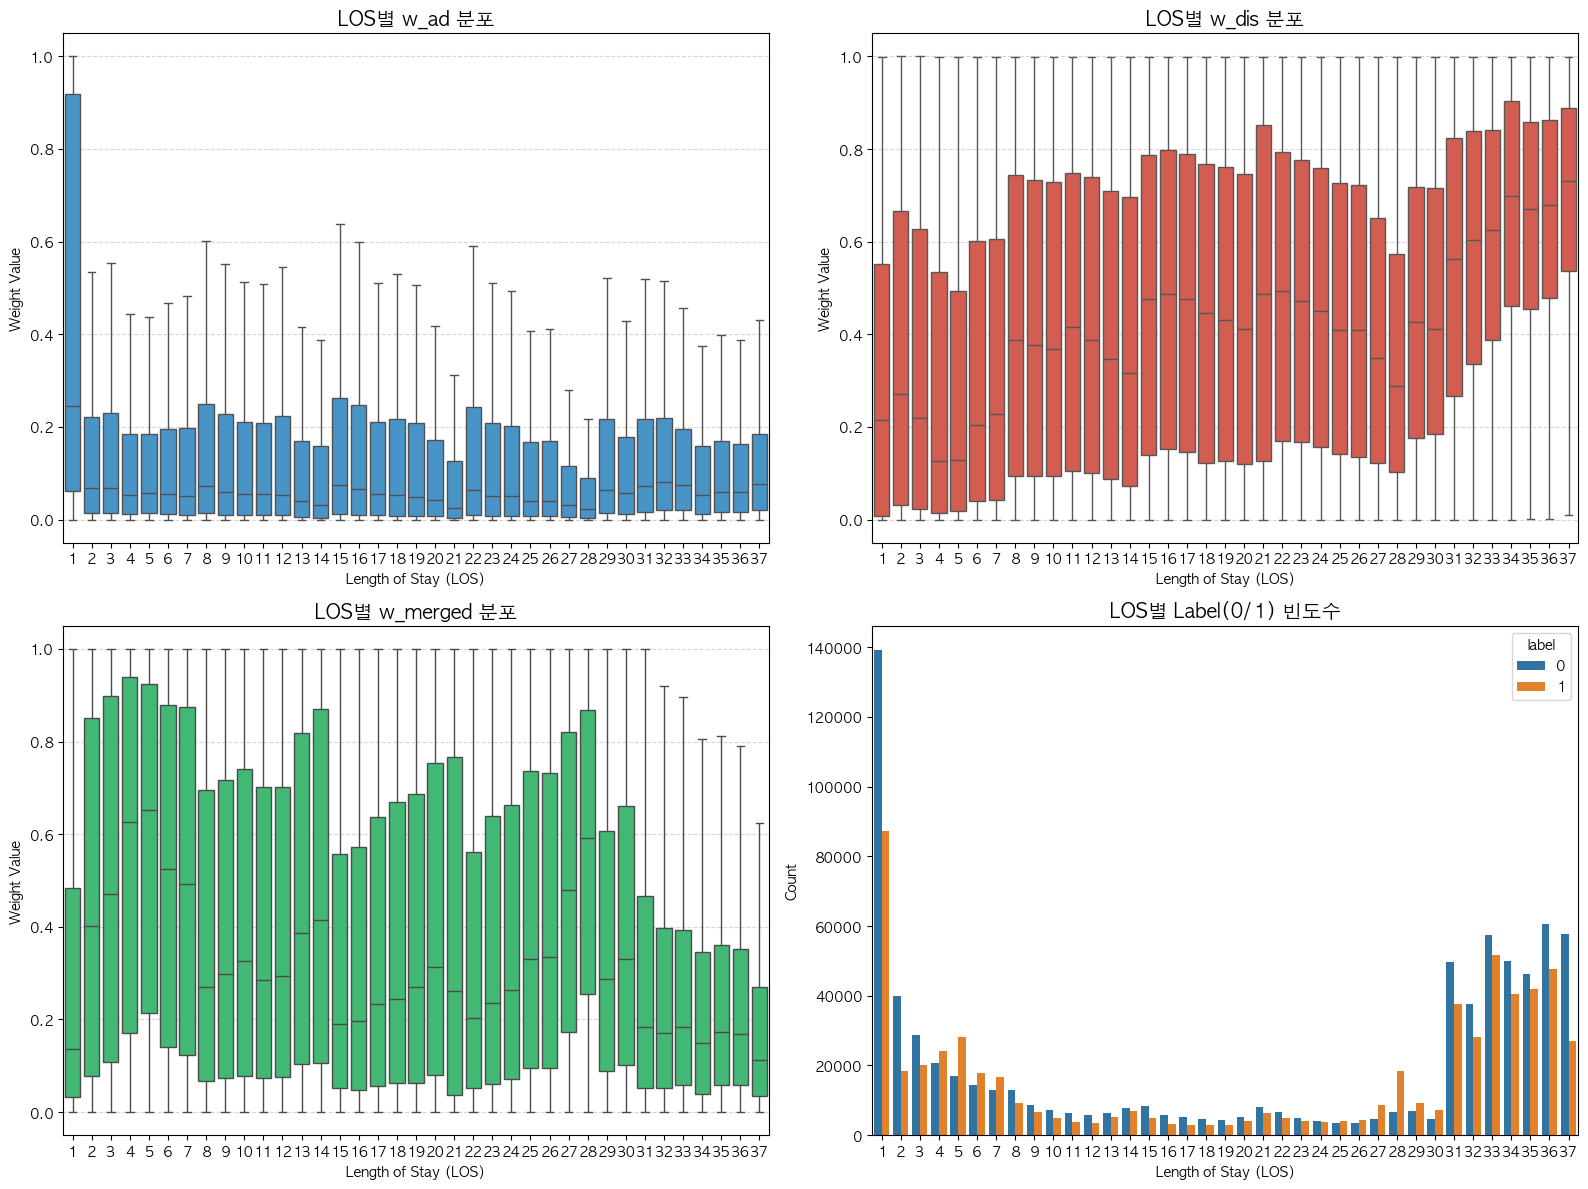

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

# LOS를 정수형으로 변환 (NaN 제거 후 변환하여 x축 눈금이 정수로 표시되도록 함)
df_w_los_plot = df_w_los.dropna(subset=['LOS']).copy()
df_w_los_plot['LOS'] = df_w_los_plot['LOS'].astype(int)

# 시각화할 변수 리스트
features = ['w_ad', 'w_dis', 'w_merged']
colors = ['#3498db', '#e74c3c', '#2ecc71'] # 각 변수별 색상 구분

# 2x2 레이아웃 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # 2차원 배열을 1차원으로 변환하여 반복문 사용 용이하게 함

# 1~3. w_ad, w_dis, w_merged 각각 그리기
for i, col in enumerate(features):
    sns.boxplot(data=df_w_los_plot, x='LOS', y=col, ax=axes[i], color=colors[i], showfliers=False)
    axes[i].set_title(f'LOS별 {col} 분포', fontsize=14)
    axes[i].set_xlabel('Length of Stay (LOS)')
    axes[i].set_ylabel('Weight Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 4. label 분포 그리기
sns.countplot(data=df_w_los_plot, x='LOS', hue='label', ax=axes[3])
axes[3].set_title('LOS별 Label(0/1) 빈도수', fontsize=14)
axes[3].set_xlabel('Length of Stay (LOS)')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df_w_los.to_csv("gated_fustion_w_los_seed_1.csv")

In [ ]:
# LOS별로 그룹화하여 요약 통계량 산출
# unstack()을 사용하면 보기 편한 형태로 펼쳐집니다.
df_summary = df_w_los.groupby('LOS')[['w_ad', 'w_dis', 'w_merged', 'label']].describe()

# 결과 확인
display(df_summary)

df_summary.to_csv("gated_fustion_w_los_seed_1.csv")

w_ad                                                              \
         count      mean       std       min       25%       50%       75%   
LOS                                                                          
1.0   226406.0  0.410784  0.385370  0.000003  0.062532  0.245890  0.918338   
2.0    58361.0  0.178828  0.255507  0.000004  0.013547  0.067593  0.222015   
3.0    49086.0  0.169729  0.235114  0.000004  0.014769  0.067278  0.230449   
4.0    44711.0  0.150469  0.224240  0.000007  0.012381  0.052750  0.184539   
5.0    45216.0  0.147906  0.215192  0.000009  0.015075  0.056558  0.184106   
6.0    32124.0  0.157133  0.229881  0.000004  0.012738  0.055387  0.194870   
7.0    29606.0  0.162460  0.242337  0.000007  0.009627  0.051752  0.198761   
8.0    22190.0  0.186026  0.252315  0.000002  0.013498  0.073051  0.248747   
9.0    15172.0  0.177468  0.253309  0.000010  0.010482  0.058951  0.227583   
10.0   12287.0  0.168147  0.246598  0.000007  0.009403  0.054321  0.211434   
11.0   10162.0  0.168072  0.245670  0.000009  0.009509  0.054387  0.209355   
12.0    9179.0  0.174420  0.254532  0.000010  0.009095  0.053083  0.223869   
13.0   11667.0  0.142277  0.226691  0.000008  0.004807  0.039649  0.169340   
14.0   14560.0  0.136089  0.223971  0.000013  0.004439  0.031714  0.157788   
15.0   13310.0  0.195423  0.264386  0.000008  0.012368  0.074819  0.263061   
16.0    9220.0  0.184284  0.254808  0.000004  0.010908  0.066573  0.246545   
17.0    8099.0  0.165302  0.241986  0.000011  0.009303  0.055174  0.209627   
18.0    7555.0  0.170125  0.250060  0.000014  0.008035  0.052007  0.217351   
19.0    7523.0  0.166432  0.248042  0.000006  0.007804  0.049443  0.207959   
20.0    9228.0  0.144865  0.227072  0.000015  0.006646  0.041685  0.171591   
21.0   14665.0  0.116794  0.203860  0.000012  0.004267  0.024837  0.127306   
22.0   11617.0  0.179868  0.250663  0.000008  0.010675  0.063473  0.242892   
23.0    8869.0  0.165674  0.244775  0.000020  0.008251  0.049950  0.209067   
24.0    7926.0  0.163695  0.244280  0.000011  0.008459  0.050408  0.202355   
25.0    7654.0  0.143739  0.226691  0.000013  0.006682  0.039587  0.166780   
26.0    7938.0  0.146643  0.232536  0.000016  0.006761  0.039938  0.169071   
27.0   13118.0  0.107885  0.186643  0.000011  0.006002  0.032185  0.115453   
28.0   24876.0  0.088467  0.166402  0.000010  0.004130  0.022902  0.089240   
29.0   16034.0  0.174688  0.245140  0.000002  0.013668  0.064482  0.216549   
30.0   11797.0  0.152481  0.222656  0.000008  0.011981  0.057392  0.178681   
31.0   87508.0  0.167851  0.225969  0.000004  0.016277  0.072443  0.217905   
32.0   65679.0  0.167723  0.217490  0.000011  0.020393  0.080034  0.218705   
33.0  108933.0  0.147135  0.189158  0.000003  0.020131  0.074844  0.194542   
34.0   90422.0  0.120836  0.168561  0.000018  0.013043  0.052795  0.157879   
35.0   88039.0  0.126573  0.168145  0.000011  0.016431  0.060067  0.169457   
36.0  108383.0  0.119663  0.156188  0.000015  0.015694  0.059304  0.164096   
37.0   84800.0  0.125267  0.141773  0.000020  0.020417  0.075750  0.184983   

                   w_dis            ...  w_merged               label  \
           max     count      mean  ...       75%       max     count   
LOS                                 ...                                 
1.0   0.999715  226406.0  0.309212  ...  0.483767  0.999958  226406.0   
2.0   0.999672   58361.0  0.364332  ...  0.850159  0.999866   58361.0   
3.0   0.999496   49086.0  0.337545  ...  0.898115  0.999941   49086.0   
4.0   0.999029   44711.0  0.288583  ...  0.939647  0.999959   44711.0   
5.0   0.998122   45216.0  0.277935  ...  0.924435  0.999950   45216.0   
6.0   0.997330   32124.0  0.331098  ...  0.878481  0.999958   32124.0   
7.0   0.998068   29606.0  0.339235  ...  0.875034  0.999981   29606.0   
8.0   0.998254   22190.0  0.430524  ...  0.695784  0.999946   22190.0   
9.0   0.997954   15172.0  0.424648  ...  0.718013  0.999894   15172.0   
10.0  0.99859

In [38]:
import os
import pandas as pd

cur_dir  = os.getcwd()
df_w_path = os.path.join(cur_dir, "gated_fusion_w_los_seed_1.csv")
df_w_los = pd.read_csv(df_w_path)
df_w_los

,Unnamed: 0,w_ad,w_ad.1,w_ad.2,w_ad.3,w_ad.4,w_ad.5,w_ad.6,w_ad.7,w_dis,...,w_merged.6,w_merged.7,label,label.1,label.2,label.3,label.4,label.5,label.6,label.7
0,NaN,count,mean,std,min,25%,50%,75%,max,count,...,75%,max,count,mean,std,min,25%,50%,75%,max
1,LOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,226406.0,0.4496356248855591,0.323527455329895,1.957702261279337e-05,0.14457643404603004,0.39253851771354675,0.7932872176170349,0.9979021549224854,226406.0,...,0.45826588571071625,0.9998743534088135,226406.0,0.3853563951485385,0.48668048042944,0.0,0.0,0.0,1.0,1.0
3,2,58361.0,0.25789934396743774,0.26051583886146545,1.1130985512863845e-05,0.04992348700761795,0.16286474466323853,0.3872512876987457,0.9981862902641296,58361.0,...,0.810018002986908,0.9996199607849121,58361.0,0.31755795822552735,0.4655304660365374,0.0,0.0,0.0,1.0,1.0
4,3,49086.0,0.25836431980133057,0.2508705258369446,9.380863048136234e-06,0.05992284044623375,0.17257414013147354,0.38440728932619095,0.9996564388275146,49086.0,...,0.8189494460821152,0.999738872051239,49086.0,0.4131727987613576,0.4924083434922426,0.0,0.0,0.0,1.0,1.0
5,4,44711.0,0.2368573695421219,0.23904184997081757,9.48619344853796e-06,0.05965103395283222,0.14613017439842224,0.3426516056060791,0.9993982315063477,44711.0,...,0.848375141620636,0.999679684638977,44711.0,0.5375410972691284,0.49859424995120577,0.0,0.0,1.0,1.0,1.0
6,5,45216.0,0.23051978647708893,0.23397000133991241,7.84268049756065e-05,0.06252795830368996,0.14589447528123856,0.3161095157265663,0.9991362690925598,45216.0,...,0.8216513842344284,0.9997988343238831,45216.0,0.622456652512385,0.4847778519510956,0.0,0.0,1.0,1.0,1.0
7,6,32124.0,0.23473906517028809,0.25106364488601685,5.259965473669581e-05,0.050531044602394104,0.13892782479524612,0.3237820938229561,0.9991872906684875,32124.0,...,0.8175940662622452,0.9998267292976379,32124.0,0.5511455609513136,0.4973849944939852,0.0,0.0,1.0,1.0,1.0
8,7,29606.0,0.22822624444961548,0.25215068459510803,1.8341899703955278e-05,0.04439536761492491,0.12770802527666092,0.3146148696541786,0.9985312223434448,29606.0,...,0.8266854882240295,0.9999054670333862,29606.0,0.5616091332837938,0.496198177147571,0.0,0.0,1.0,1.0,1.0
9,8,22190.0,0.24472492933273315,0.256631463766098,2.428618972771801e-05,0.048378597013652325,0.14978914707899094,0.3460830897092819,0.9985643029212952,22190.0,...,0.738784670829773,0.9995710253715515,22190.0,0.4182063992789545,0.4932755540421306,0.0,0.0,0.0,1.0,1.0


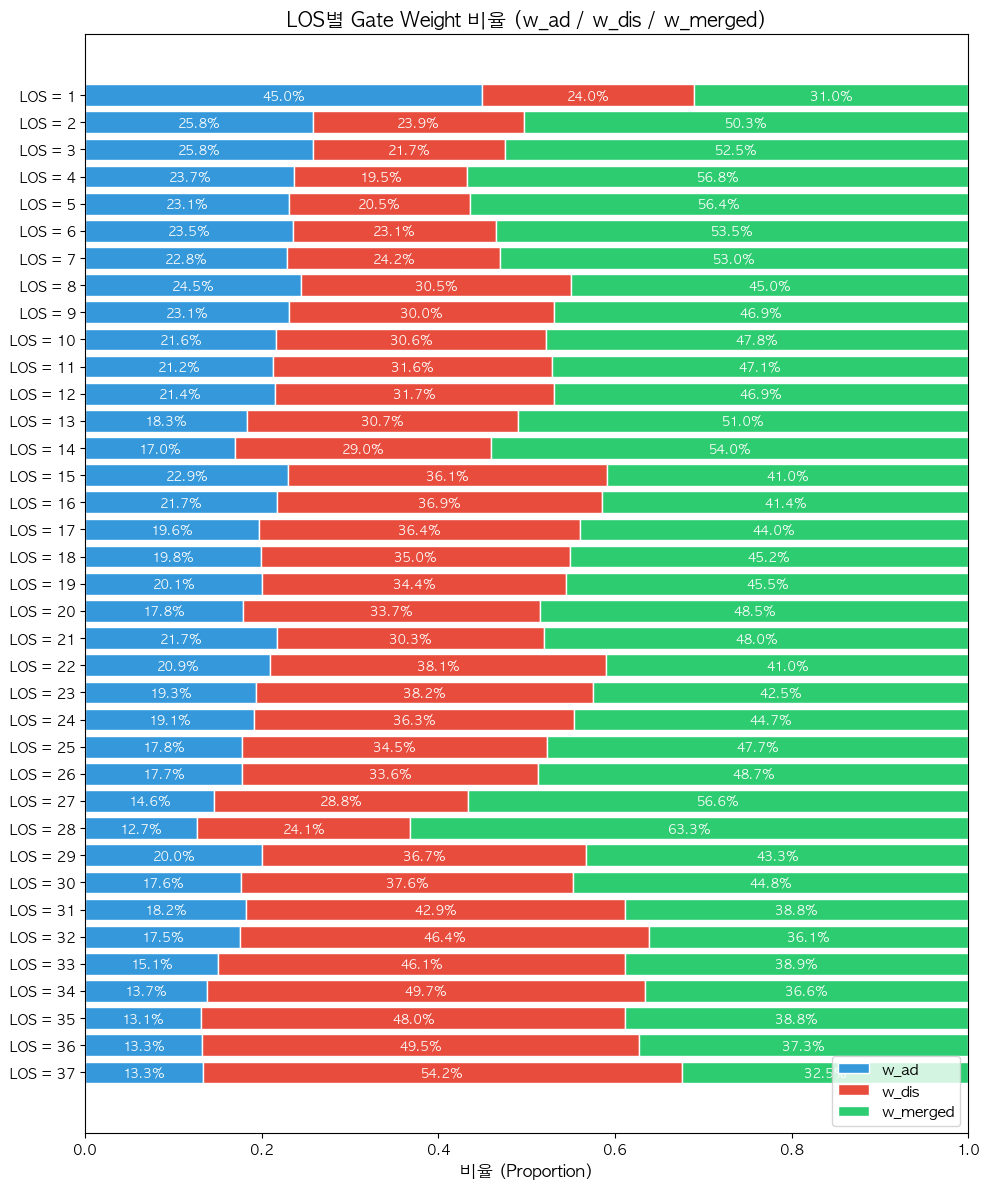

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# gated_fusion_w_los_seed_1.csv 로드 (describe() 결과 - 멀티레벨 헤더)
cur_dir = os.path.dirname(os.path.abspath("gated_fusion.ipynb"))
csv_path = os.path.join(cur_dir, "gated_fusion_w_los_seed_1.csv")

df_summary = pd.read_csv(csv_path, header=[0, 1], index_col=0)
df_summary.index = df_summary.index.astype(int)

# 각 LOS별 w_ad, w_dis, w_merged 평균값 추출
means = pd.DataFrame({
    "w_ad":     df_summary[("w_ad",     "mean")],
    "w_dis":    df_summary[("w_dis",    "mean")],
    "w_merged": df_summary[("w_merged", "mean")],
})

# 비율로 정규화
proportions = means.div(means.sum(axis=1), axis=0)

# 시각화
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 12))

colors = ["#3498db", "#e74c3c", "#2ecc71"]
col_names = ["w_ad", "w_dis", "w_merged"]
los_labels = [f"LOS = {v}" for v in proportions.index]

left = [0.0] * len(proportions)
for col, color in zip(col_names, colors):
    values = proportions[col].values
    bars = ax.barh(los_labels, values, left=left, color=color, label=col, edgecolor="white")
    for bar, val, l in zip(bars, values, left):
        if val > 0.05:
            ax.text(l + val / 2, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1%}", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    left = [l + v for l, v in zip(left, values)]

ax.set_xlabel("비율 (Proportion)", fontsize=12)
ax.set_title("LOS별 Gate Weight 비율 (w_ad / w_dis / w_merged)", fontsize=14)
ax.set_xlim(0, 1)
ax.legend(loc="lower right", fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.show()